## TADKit - CAD, Conformal Anomaly Detection demonstrator

This notebook demonstrates how to implement the CAD framework by combining TADkit learners with the PUNCC library.

NB: note that the focus is on technical inter-operability, not functional results.

<Axes: >

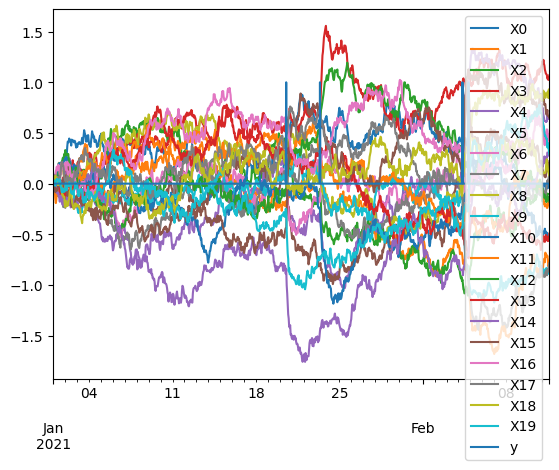

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ouagen import ornstein_uhlenbeck_anomaly


t = np.arange(1000)
t = t / t.shape[0]
pre_X, pre_y = ornstein_uhlenbeck_anomaly(
    t,
    size=20,
    noise_scale=1,
    mean_reverting=3,
    anomaly_freq=.1,
    anomaly_duration=0.005,
    anomaly_scale=40,
)
t = pd.to_datetime('2021-01-01') + pd.Timedelta(1, 'h') * np.arange(t.shape[0])
X = pd.DataFrame(pre_X, index=t, columns=[f'X{i}' for i in range(pre_X.shape[1])])
y = pd.DataFrame(pre_y[:, None], index=t, columns=['y'])
async_X = X.melt(value_vars=X.columns.tolist(), ignore_index=False).rename(
    columns={"variable": "sensor", "value": "data"}
)
oua = pd.concat([X, y], axis=1)
oua.plot()

In [2]:
cut1, cut2 = X.index[X.shape[0]//3], X.index[2*X.shape[0]//3]
cut1, cut2

(Timestamp('2021-01-14 21:00:00'), Timestamp('2021-01-28 18:00:00'))

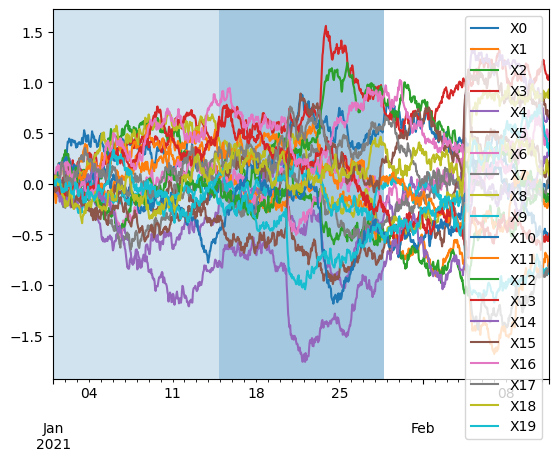

In [3]:
X_train = X.loc[:cut1, :]
y_train = y.loc[:cut1]
X_calib = X.loc[cut1:cut2:, :]
y_calib = y.loc[cut1:cut2]

ax = X.plot()
ax.axvspan(X_train.index[0], X_train.index[-1], alpha=0.2)
ax.axvspan(X_calib.index[0], X_calib.index[-1], alpha=0.4)
plt.show()

In [6]:
from tadkit.base.registry import registry
import tadkit.catalog.registry_init  # ensure registrations happen

registry.print_catalog_classes()
registry.list_learners()
registry.match_learners()

[TADkit registered Catalog]
Class learner_name='IsolationForest' is registered in TADKit.
IsolationForest is operational in this environment.
IsolationForest is implicit child of TADLearner.
Class learner_name='KDEOutlierDetector' is registered in TADKit.
KDEOutlierDetector is operational in this environment.
KDEOutlierDetector is implicit child of TADLearner.
Class learner_name='GMMOutlierDetector' is registered in TADKit.
GMMOutlierDetector is operational in this environment.
GMMOutlierDetector is implicit child of TADLearner.
Class learner_name='TopologicalAnomalyDetector' is registered in TADKit.
TopologicalAnomalyDetector is operational in this environment.
TopologicalAnomalyDetector is implicit child of TADLearner.
Class learner_name='KcpLearner' is registered in TADKit.
KcpLearner is operational in this environment.
KcpLearner is implicit child of TADLearner.


[sklearn.ensemble._iforest.IsolationForest,
 tadkit.catalog.sklearners.KDEOutlierDetector,
 tadkit.catalog.sklearners.GMMOutlierDetector,
 tdaad.anomaly_detectors.TopologicalAnomalyDetector,
 kcpdi.kcp_ss_learner.KcpLearner]

In [22]:
# puncc imports and wrapper
from deel.puncc.anomaly_detection import SplitCAD
from deel.puncc.api.prediction import BasePredictor
# The nonconformity scores are defined as the IF scores (anomaly score).
# By default, score_samples return the opposite of IF scores.
# We need to redefine the predict to output the nonconformity scores.
class ADPredictor(BasePredictor):
    def predict(self, X):
        return -self.model.score_samples(X)

# We set the maximum false detection rate to 5%
alpha = 0.05

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

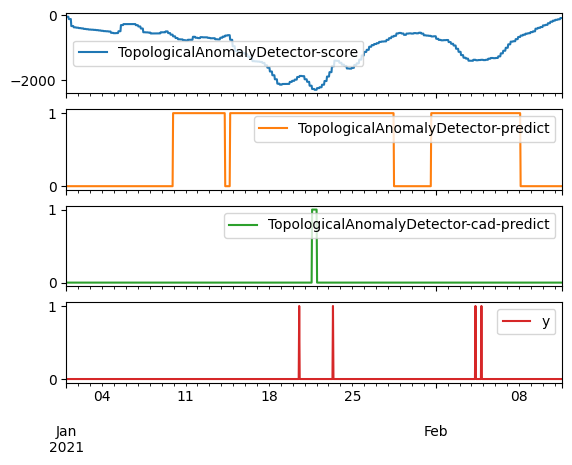

In [23]:
learner_class = registry.match_learners()[3]
name = learner_class.__name__

results = {}
results[name] = pd.DataFrame(index=X.index)
learner = learner_class().fit(X_train)
results[name][f"{name}-score"] = learner.score_samples(X)
results[name][f"{name}-predict"] = 1-(learner.predict(X)+1)//2

if_predictor = ADPredictor(learner_class())
# Instantiate CAD on top of IF predictor
if_cad = SplitCAD(if_predictor, train=True, random_state=0)

if_cad.fit(z_fit=X_train, z_calib=X_calib)

# The method `predict` is calledµ on the new data points
# to test which are anomalous and which are not
results[name][f"{name}-cad-predict"] = if_cad.predict(X, alpha=alpha).astype(int)

pd.concat([results[name], y], axis=1).plot(subplots=True)